CELL NÀY BẮT BUỘC PHẢI CÓ

In [15]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent   # Data-mining/
sys.path.append(str(PROJECT_ROOT))

In [ ]:
# Libraries
import numpy as np
import pandas as pd
from sklearn import *
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
from charset_normalizer.cd import encoding_unicode_range
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# Preprocessing
from src.preprocessing import *

path = "..\\data\\jewelry.csv"
column_names = [
    'event_time',    # Thời gian mua hàng
    'order_id',      # Mã đơn hàng
    'product_id',    # Mã sản phẩm
    'quantity',      # Số lượng
    'category_id',   # Mã danh mục
    'category_code', # Tên loại trang sức
    'brand_id',      # Mã thương hiệu
    'price',         # Giá tiền
    'user_id',       # Mã khách hàng
    'gender',        # Giới tính
    'color',         # Màu sắc (red, white, gold...)
    'metal',         # Chất liệu kim loại (gold, silver...)
    'gem'            # Loại đá quý (diamond, sapphire...)
]

# Ép về string
# tránh để string dài quá đọc csv sẽ tự chuyển sang int64
dtype_specs = {
    'order_id': str,
    'product_id': str,
    'category_id': str,
    'brand_id': str,
    'user_id': str,
    'category_code': str
}
dataset = pd.read_csv(path, header=None, names=column_names, dtype=dtype_specs)
data_outputs = master_preprocessing_pipeline(dataset)
df_main = data_outputs['main_clean']
df_rules = data_outputs['rules_data']
df_users = data_outputs['user_profile']

ModuleNotFoundError: No module named 'src'

In [17]:
df_main.info()

<class 'pandas.DataFrame'>
Index: 90559 entries, 0 to 95910
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   event_time             90559 non-null  datetime64[us, UTC]
 1   order_id               90559 non-null  str                
 2   product_id             90559 non-null  str                
 3   quantity               90559 non-null  int64              
 4   category_id            90559 non-null  str                
 5   category_code          90559 non-null  str                
 6   brand_id               90559 non-null  str                
 7   price                  90559 non-null  float64            
 8   user_id                90559 non-null  str                
 9   gender                 90559 non-null  str                
 10  color                  90559 non-null  str                
 11  metal                  90559 non-null  str                
 12  gem   

In [18]:
main = pd.read_pickle("../data/processed/main_clean.pkl")
rules = pd.read_pickle("../data/processed/rules_data.pkl")
user = pd.read_pickle("../data/processed/user_profile.pkl")
print(main.loc[main['hour'] < 6, ['hour']])

       hour
95        3
210       2
211       2
235       1
236       2
...     ...
95793     5
95794     5
95795     5
95796     5
95798     5

[6139 rows x 1 columns]


In [19]:
main["order_line_value"] = main["price"] * main["quantity"]

In [20]:
order_df = (
    main.groupby("order_id")
    .agg(
        order_value=("order_line_value", "sum"),
        hour=("hour", "first"),
        day_of_week=("day_of_week", "first"),
        is_weekend=("is_weekend", "first"),
        user_id=("user_id", "first")
    )
    .reset_index()
)

In [21]:
order_df = order_df.merge(user, on="user_id", how="left")

In [22]:
def time_bucket(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 11:
        return "Morning"
    elif 11 <= hour < 14:
        return "Noon"
    elif 14 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

order_df["time_bucket"] = order_df["hour"].apply(time_bucket)

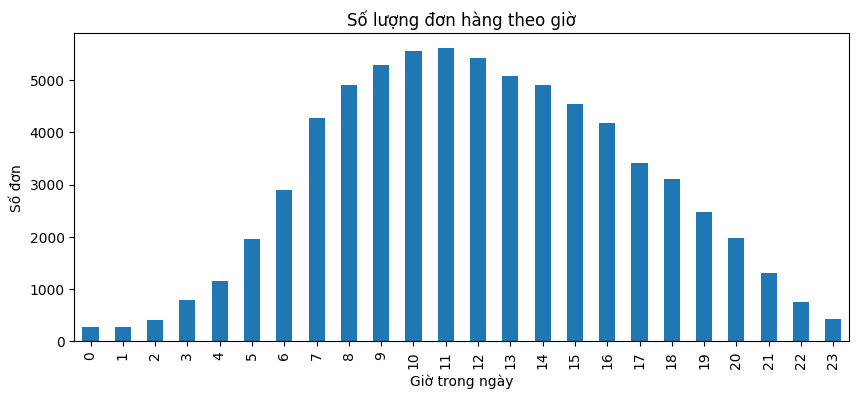

In [23]:
orders_per_hour = order_df.groupby("hour")["order_id"].count()

plt.figure(figsize=(10,4))
orders_per_hour.plot(kind="bar")
plt.title("Số lượng đơn hàng theo giờ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Số đơn")
plt.show()

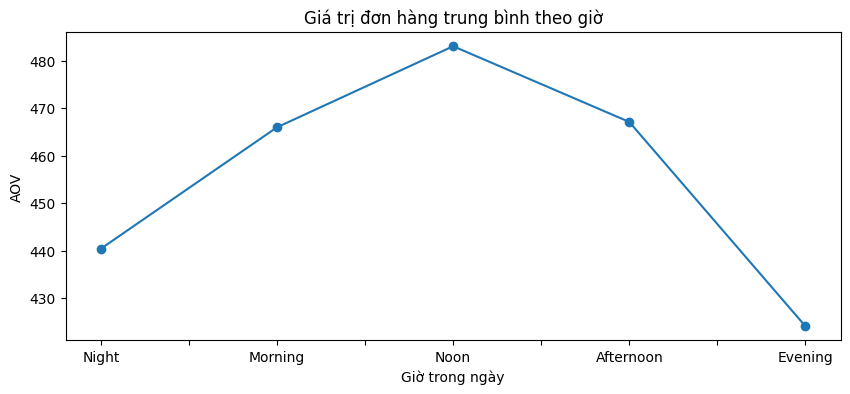

In [24]:
time_order = ["Night", "Morning", "Noon", "Afternoon", "Evening"]
aov_per_hour = (order_df.groupby("time_bucket")["order_value"].mean().reindex(time_order))

plt.figure(figsize=(10,4))
aov_per_hour.plot(kind="line", marker="o")
plt.title("Giá trị đơn hàng trung bình theo giờ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("AOV")
plt.show()

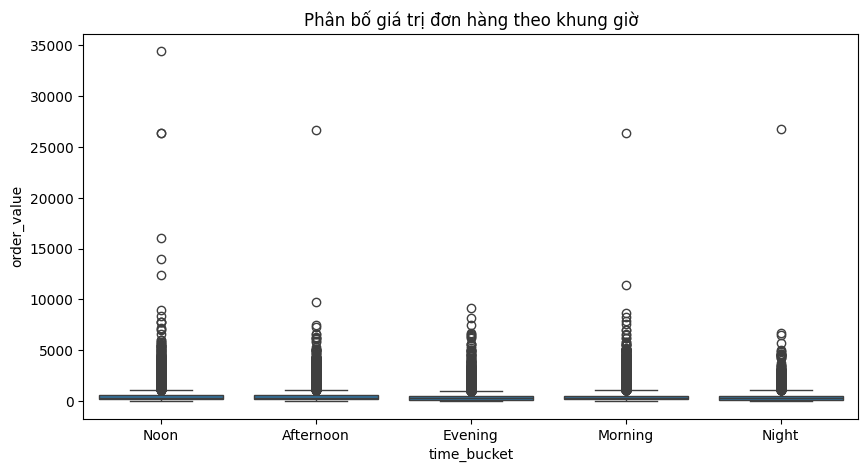

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x="time_bucket", y="order_value", data=order_df)
plt.title("Phân bố giá trị đơn hàng theo khung giờ")
plt.show()

In [26]:
groups = [
    order_df[order_df["time_bucket"] == g]["order_value"]
    for g in order_df["time_bucket"].unique()
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 16.533236383044414
p-value: 1.5067401674030758e-13


In [27]:
tukey = pairwise_tukeyhsd(
    endog=order_df["order_value"],
    groups=order_df["time_bucket"],
    alpha=0.05
)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2 meandiff p-adj   lower    upper  reject
---------------------------------------------------------
Afternoon Evening  -42.947    0.0 -63.8601 -22.034   True
Afternoon Morning   -1.124 0.9998 -17.9449 15.6969  False
Afternoon   Night -26.6493 0.0555 -53.6816  0.3829  False
Afternoon    Noon  15.9171 0.1218  -2.3549 34.1892  False
  Evening Morning   41.823    0.0  21.9338 61.7123   True
  Evening   Night  16.2977 0.5423 -12.7434 45.3387  False
  Evening    Noon  58.8641    0.0  37.7334 79.9949   True
  Morning   Night -25.5254 0.0612 -51.7736  0.7229  False
  Morning    Noon  17.0411 0.0511  -0.0497 34.1319  False
    Night    Noon  42.5665 0.0002  15.3654 69.7675   True
---------------------------------------------------------


In [28]:
evening = order_df[order_df["time_bucket"] == "Evening"]["order_value"]
night = order_df[order_df["time_bucket"] == "Night"]["order_value"]

t_stat, p_val = ttest_ind(evening, night, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_val)

T-statistic: -1.506321190812882
p-value: 0.13202314733980164


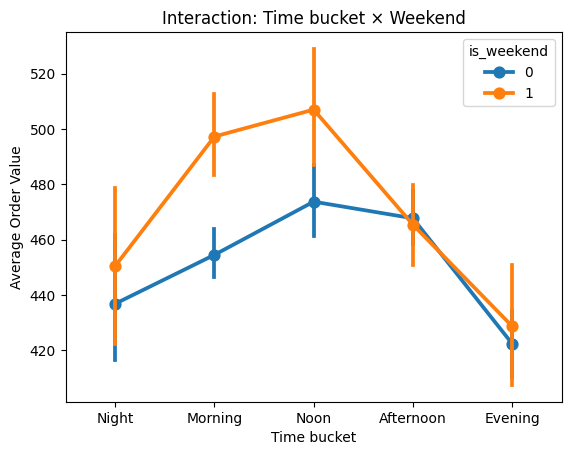

In [33]:
time_order = ["Night", "Morning", "Noon", "Afternoon", "Evening"]
order_df["time_bucket"] = pd.Categorical(
    order_df["time_bucket"],
    categories=time_order,
    ordered=True
)
sns.pointplot(
    data=order_df,
    x="time_bucket",
    y="order_value",
    hue="is_weekend",
    errorbar=('ci', 95)
)
plt.title("Interaction: Time bucket × Weekend")
plt.xlabel("Time bucket")
plt.ylabel("Average Order Value")
plt.show()